In [2]:
def update_lr(self, current_epoch: int, total_epochs: int):
    """
    Linearly decays the learning rate from its initial value down to 0
    over the course of training.
    """
    # Get initial LR from optimizer param groups
    initial_lr = (
        self.optimizer.param_groups[0]["initial_lr"]
        if "initial_lr" in self.optimizer.param_groups[0]
        else self.optimizer.param_groups[0]["lr"]
    )

    # Save it if not already saved
    if "initial_lr" not in self.optimizer.param_groups[0]:
        self.optimizer.param_groups[0]["initial_lr"] = initial_lr

    fraction = 1.0 - (current_epoch - 1.0) / total_epochs
    new_lr = initial_lr * max(0.0, fraction)

    for param_group in self.optimizer.param_groups:
        param_group["lr"] = new_lr

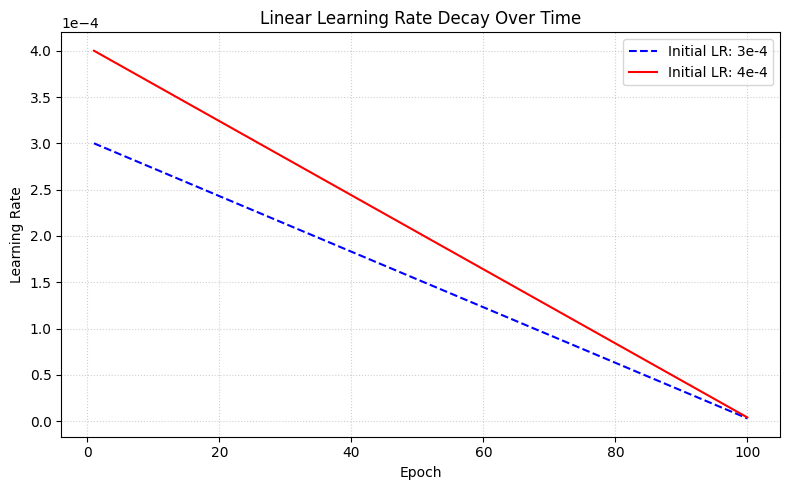

In [3]:
import matplotlib.pyplot as plt


def calculate_lr(initial_lr: float, current_epoch: int, total_epochs: int) -> float:
    """
    Mimics the logic inside the update_lr method.
    """
    fraction = 1.0 - (current_epoch - 1.0) / total_epochs
    new_lr = initial_lr * max(0.0, fraction)
    return new_lr


# Configuration
total_epochs = 100
epochs = list(range(1, total_epochs + 1))

# Calculate learning rates for both initial values
lrs_3e4 = [calculate_lr(3e-4, epoch, total_epochs) for epoch in epochs]
lrs_4e4 = [calculate_lr(4e-4, epoch, total_epochs) for epoch in epochs]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(epochs, lrs_3e4, label="Initial LR: 3e-4", color="blue", linestyle="--")
plt.plot(epochs, lrs_4e4, label="Initial LR: 4e-4", color="red", linestyle="-")

# Formatting the plot
plt.title("Linear Learning Rate Decay Over Time")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

# Displaying scientific notation on y-axis clearly
plt.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
r"C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2\output_1\alpha_cache_41d_1998_0.parquet"

In [ ]:
import pandas as pd

path = r"C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2\output_1\alpha_cache_41d_1998_0.parquet"
df_0 = pd.read_parquet(path)

41d_Log Price Gain  41d_Sharpe (TRP)  41d_Momentum (21d)  \
Date       Ticker                                                             
1998-01-02 AA               -0.034436         -0.028711            0.045871   
           AAPL             -0.066945         -0.013536            0.023618   
           ABT               0.080043          0.091917            0.002787   
           ADBE             -0.187495         -0.078553           -0.026571   
           ADI              -0.147325         -0.067865           -0.118000   

                   41d_Info Ratio (63d)  41d_Oversold (-RSI)  \
Date       Ticker                                              
1998-01-02 AA                 -0.159439            -0.112524   
           AAPL               -0.096406            -0.209061   
           ABT                 0.043385            -0.112329   
           ADBE               -0.110280            -0.052140   
           ADI                -0.086074             0.025183   

                   41d_Dip Buyer (-dd_21)  41d_Range Position (20d)  \
Date       Ticker                                                     
1998-01-02 AA                    0.008696                  0.720426   
           AAPL                 -0.000000                  1.000000   
           ABT                   0.017304                  0.741061   
           ADBE                  0.046612                  0.738844   
           ADI                   0.100000                  0.512603   

                   41d_Return Autocorr (15d)  41d_Low Volatility (-ATRP)  \
Date       Ticker                                                          
1998-01-02 AA                       0.017868                   -0.027014   
           AAPL                     0.063373                   -0.054680   
           ABT                     -0.072063                   -0.025176   
           ADBE                     0.070294                   -0.048751   
           ADI                      0.043087                   -0.050634   

                   41d_Slope_P_5_Z  41d_Slope_V_5_Z  41d_Convexity  
Date       Ticker                                                   
1998-01-02 AA             1.164838         1.174724       0.008226  
           AAPL           2.510492         0.735531       0.036047  
           ABT            0.843948         0.593289      -0.002345  
           ADBE           1.736307         1.334331      -0.002425  
           ADI            0.886744         0.908944       0.000841

In [3]:
path = r"C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2\output_1\alpha_cache_41d_1998_1.parquet"
df_1 = pd.read_parquet(path)

In [4]:
path = r"C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2\output_1\alpha_cache_41d_1998_2.parquet"
df_2 = pd.read_parquet(path)

In [2]:
df_0.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 3060136 entries, (Timestamp('1998-01-02 00:00:00'), 'AA') to (Timestamp('2019-06-20 00:00:00'), 'ZTS')
Data columns (total 12 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   41d_Log Price Gain          float64
 1   41d_Sharpe (TRP)            float64
 2   41d_Momentum (21d)          float64
 3   41d_Info Ratio (63d)        float64
 4   41d_Oversold (-RSI)         float64
 5   41d_Dip Buyer (-dd_21)      float64
 6   41d_Range Position (20d)    float64
 7   41d_Return Autocorr (15d)   float64
 8   41d_Low Volatility (-ATRP)  float64
 9   41d_Slope_P_5_Z             float64
 10  41d_Slope_V_5_Z             float64
 11  41d_Convexity               float64
dtypes: float64(12)
memory usage: 292.0+ MB


In [5]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 3556445 entries, (Timestamp('1998-01-02 00:00:00'), 'AA') to (Timestamp('2021-11-04 00:00:00'), 'ZTS')
Data columns (total 12 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   41d_Log Price Gain          float64
 1   41d_Sharpe (TRP)            float64
 2   41d_Momentum (21d)          float64
 3   41d_Info Ratio (63d)        float64
 4   41d_Oversold (-RSI)         float64
 5   41d_Dip Buyer (-dd_21)      float64
 6   41d_Range Position (20d)    float64
 7   41d_Return Autocorr (15d)   float64
 8   41d_Low Volatility (-ATRP)  float64
 9   41d_Slope_P_5_Z             float64
 10  41d_Slope_V_5_Z             float64
 11  41d_Convexity               float64
dtypes: float64(12)
memory usage: 339.4+ MB


In [6]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 4622726 entries, (Timestamp('1998-01-02 00:00:00'), 'AA') to (Timestamp('2026-07-10 00:00:00'), 'ZTS')
Data columns (total 12 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   41d_Log Price Gain          float64
 1   41d_Sharpe (TRP)            float64
 2   41d_Momentum (21d)          float64
 3   41d_Info Ratio (63d)        float64
 4   41d_Oversold (-RSI)         float64
 5   41d_Dip Buyer (-dd_21)      float64
 6   41d_Range Position (20d)    float64
 7   41d_Return Autocorr (15d)   float64
 8   41d_Low Volatility (-ATRP)  float64
 9   41d_Slope_P_5_Z             float64
 10  41d_Slope_V_5_Z             float64
 11  41d_Convexity               float64
dtypes: float64(12)
memory usage: 441.2+ MB


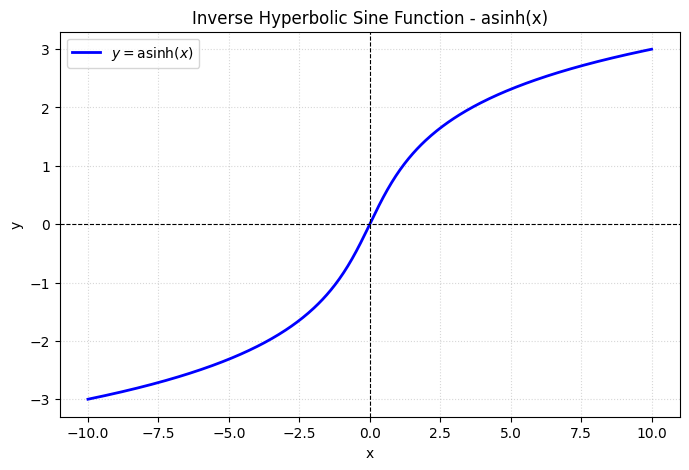

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values
x = np.linspace(-10, 10, 400)
y = np.arcsinh(x)  # numpy uses arcsinh for asinh

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r"$y = \operatorname{asinh}(x)$", color="blue", linewidth=2)

# Format the grid and axes
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.grid(True, which="both", linestyle=":", alpha=0.5)

plt.title("Inverse Hyperbolic Sine Function - asinh(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()

In [9]:
from pathlib import Path
import ast

base = Path(r"C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2")

EXCLUDE_DIRS = {"archive", "output", "data", "tests", "__pycache__"}
EXCLUDE_FILES = {
    "utils",
    "__init__",
}  # any file whose name contains one of these

for f in sorted(base.rglob("*")):
    if not f.is_file():
        continue
    rel = f.relative_to(base)
    if any(part in EXCLUDE_DIRS for part in rel.parts[:-1]):
        continue
    if any(pat in f.name for pat in EXCLUDE_FILES):
        continue
    print(rel)
    if f.suffix == ".py":
        try:
            tree = ast.parse(f.read_text(encoding="utf-8"))
        except (SyntaxError, UnicodeDecodeError):
            continue
        for node in tree.body:
            if isinstance(node, ast.ClassDef):
                print(f"    class {node.name}")

00_RLVR_data_process_v6.ipynb
01_RLVR_Part1_AlphaCache_v4.ipynb
02_RLVR_Part2_Training_v15.ipynb
03_RLVR_Part3_Analysis_v3.ipynb
_trash.ipynb
_trash.md
_trash.txt
codebase2.txt
core\auditor.py
    class SystemAuditor
core\contracts.py
    class MarketObservation
    class FilterPack
    class EngineInput
    class EngineOutput
    class SelectionResult
    class DiscoveryResult
    class MetricBlueprint
core\logic.py
    class AlphaLogic
    class SelectionLogic
core\paths.py
core\quant.py
    class QuantUtils
    class TickerEngine
core\result.py
    class TaskResult
    class HeadlessReporter
core\settings.py
    class CacheConfig
    class StrategyParams
    class QualityThresholds
    class TradingConfig
data_pipeline\builder.py
    class MacroFeaturePipeline
    class MicroFeaturePipeline
    class QualityFilterPipeline
data_pipeline\cache.py
    class AlphaCache
    class CheckpointAlphaCache
data_pipeline\loader.py
data_pipeline\screener.py
    class UniverseScreener
features_df

In [ ]:
from pathlib import Path

base = Path(r"C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2")

EXCLUDE_DIRS = {"archive", "output", "data", "tests", "__pycache__"}
EXCLUDE_FILES = {
    "utils",
    "__init__",
}  # any file whose name contains one of these

for f in base.rglob("*"):
    if not f.is_file():
        continue
    rel = f.relative_to(base)
    if any(part in EXCLUDE_DIRS for part in rel.parts[:-1]):
        continue
    if any(pat in f.name for pat in EXCLUDE_FILES):
        continue
    print(rel)

00_RLVR_data_process_v6.ipynb
01_RLVR_Part1_AlphaCache_v4.ipynb
02_RLVR_Part2_Training_v15.ipynb
03_RLVR_Part3_Analysis_v3.ipynb
codebase2.txt
features_df_out.xlsx
fed_data_yield_spread.ipynb
main.ipynb
main.py
metric_definitions.md
nb2txt.ipynb
nb2txt.py
observation_action_dimensions.md
run_pipeline.ipynb
run_pipeline.py
teir_1_files.txt
TODO.md
troubleshoot.md
verify_alphacache.ipynb
verify_rlvr_pipeline_v1.ipynb
verify_UI_n_features_calc.xlsx
verify_UI_n_features_calc_v4.ipynb
yt_audio.ipynb
_trash.ipynb
_trash.md
_trash.txt
core\auditor.py
core\contracts.py
core\logic.py
core\paths.py
core\quant.py
core\result.py
core\settings.py
data_pipeline\builder.py
data_pipeline\cache.py
data_pipeline\loader.py
data_pipeline\screener.py
rl_discovery\adapter.py
rl_discovery\agent.py
rl_discovery\environment.py
rl_discovery\oracle.py
rl_discovery\trainer.py
rl_discovery\validator.py
strategy\registry.py
tests\test_alpha_cache.py
tests\test_audit_pipeline.py
tests\test_data_process.py
tests\test

In [2]:
from pathlib import Path

for f in Path("C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2").rglob(
    "*"
):
    if f.is_file():
        print(f)

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (1927917051.py, line 3)

In [4]:
from pathlib import Path

base = Path(r"C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2")

for f in base.rglob("*"):
    if f.is_file():
        print(f.relative_to(base))

00_RLVR_data_process_v6.ipynb
01_RLVR_Part1_AlphaCache_v4.ipynb
02_RLVR_Part2_Training_v15.ipynb
03_RLVR_Part3_Analysis_v3.ipynb
codebase2.txt
features_df_out.xlsx
fed_data_yield_spread.ipynb
main.ipynb
main.py
metric_definitions.md
nb2txt.ipynb
nb2txt.py
observation_action_dimensions.md
run_pipeline.ipynb
run_pipeline.py
teir_1_files.txt
TODO.md
troubleshoot.md
verify_alphacache.ipynb
verify_rlvr_pipeline_v1.ipynb
verify_UI_n_features_calc.xlsx
verify_UI_n_features_calc_v4.ipynb
yt_audio.ipynb
_trash.ipynb
_trash.md
_trash.txt
archive\00_RLVR_data_process_v0.ipynb
archive\00_RLVR_data_process_v1.ipynb
archive\00_RLVR_data_process_v2.ipynb
archive\00_RLVR_data_process_v3.ipynb
archive\00_RLVR_data_process_v4.ipynb
archive\00_RLVR_data_process_v5.ipynb
archive\01_RLVR_Part1_AlphaCache_v3.ipynb
archive\02_RLVR_Part2_Training_v10.ipynb
archive\02_RLVR_Part2_Training_v11.ipynb
archive\02_RLVR_Part2_Training_v12.ipynb
archive\02_RLVR_Part2_Training_v13.ipynb
archive\02_RLVR_Part2_Training_v

In [3]:
from pathlib import Path

for f in Path(r"C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2").rglob(
    "*"
):
    if f.is_file():
        print(f)

C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2\00_RLVR_data_process_v6.ipynb
C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2\01_RLVR_Part1_AlphaCache_v4.ipynb
C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2\02_RLVR_Part2_Training_v15.ipynb
C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2\03_RLVR_Part3_Analysis_v3.ipynb
C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2\codebase2.txt
C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2\features_df_out.xlsx
C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2\fed_data_yield_spread.ipynb
C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2\main.ipynb
C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2\main.py
C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2\metric_definitions.md
C:\Users\ping\Files_win10\python\py311\stocks\notebooks_RLVR_v2\nb2txt.ipynb
C:\Users\ping\Files_win10\python\py311\stocks\note